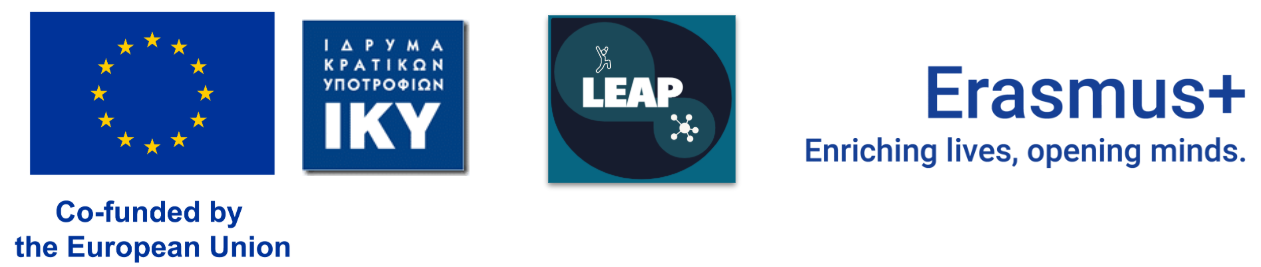

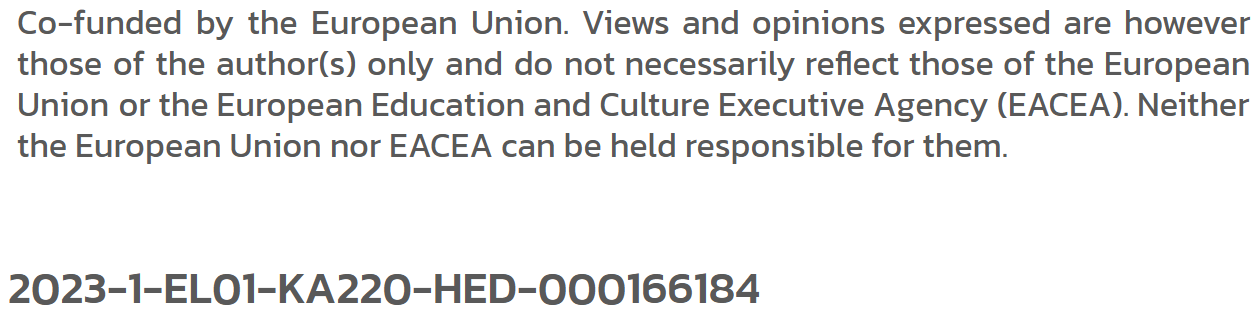

# Final Project, Option 3: How much structure can you find without the labels?

**Author:** SKOUDAROPOULOU CHRYSOSTOMI ATHINA
**Course:** Machine Learning with Python
**Date:** 4 OCTOBER 2026

## Introduction

In this project I explored the Seeds data set, which contains 210 wheat kernels described by seven geometric measurements. The variety labels were set aside at the start and used only at the very end as an external check.

The central question was: **how much of the real variety structure can be recovered using clustering alone?**

I followed the workflow from Module 4:
1. Scaled the seven features with StandardScaler.
2. Reduced them to two dimensions with PCA for visualisation.
3. Applied K-Means clustering.
4. Chose the number of clusters using the elbow method and the silhouette score.
5. Validated the result against the true varieties using a cross-tabulation and a purity score.

## Results summary

- **Chosen k:** 3
- **Purity score:** 0.919
- **Explained variance (2 PCA components):** 88.9%
- **Main finding:** the three clusters matched the three real varieties closely, with only a small number of kernels crossing between clusters.

# Final Project, Option 3: How much structure can you find without the labels?

An agricultural co-op receives unlabelled deliveries of mixed wheat grain and wants to know how many distinct varieties are present, and how cleanly they separate, before committing to any sorting process. In this project you recover that structure using clustering alone.

In this project you take a data set with a known grouping, hide that grouping from yourself, and see how much of it you can recover using clustering alone. The labels are kept aside until the very end, where they serve only as an answer key.

**Central question:** how much of the real class structure can you recover without ever using the labels?

The data set is Seeds: 210 wheat kernels described by seven geometric measurements such as area, perimeter, and kernel length. You are given the measurements to work with, and the variety labels are set aside for the final check.

This project draws on Module 4. There we scaled features, reduced them with PCA, clustered with K-Means, chose the number of clusters using the elbow and silhouette methods, and validated the result against a known label with a cross-tabulation. Here you carry out that whole process yourself and judge how faithfully the clusters match the real varieties.

**How this notebook is organised.** The cells in Part A are already written for you. They handle the import, the download, and the scaling. From Part B onward, the cells are yours to complete. Each one carries comments describing what to do, along with a few hints, but not the finished code. Work through them in order, and resist looking at the varieties until Part D.

## Part A. Setup and data

We start with the imports. This cell loads everything the notebook needs, so we run it once at the top.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Loading the data

We download the Seeds data set. The seven measurements go into `X`, and the true varieties go into `y_true`. We put the varieties aside now and do not touch them until Part D, so that the clustering is done with no knowledge of the answer.

In [3]:
# The Seeds data set: 210 kernels described by seven geometric measurements.
# It is small and fully numeric,
# which suits clustering well.
feature_names = ["area", "perimeter", "compactness", "kernel_length",
                 "kernel_width", "asymmetry", "groove_length"]

seeds = fetch_openml(name="seeds", version=1, as_frame=True)

X = seeds.data.copy()
X.columns = feature_names          # give the seven measurements readable names

# The true varieties. We set these aside now and do NOT use them until Part D,
# where they serve only as an external check on the clustering.
y_true = seeds.target.to_numpy().astype(int)

print("Rows and features:", X.shape)
X.head()

Rows and features: (210, 7)


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


### Scaling the features

Clustering relies on distances between points, so a feature measured on a larger scale would count for more than the others. We put every feature on the same footing with `StandardScaler`, as in Module 4.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled feature matrix:", X_scaled.shape)

Scaled feature matrix: (210, 7)


## Part B. Explore, without labels

From here on, the cells are yours to complete.

First, look at the shape of the data. Seven measurements are too many to plot at once, so reduce them to two with PCA and draw a scatter. This is the same reduction you used in Module 4.

Explained variance ratio: [0.71874303 0.17108184]
Total variance kept: 0.8898248618491232


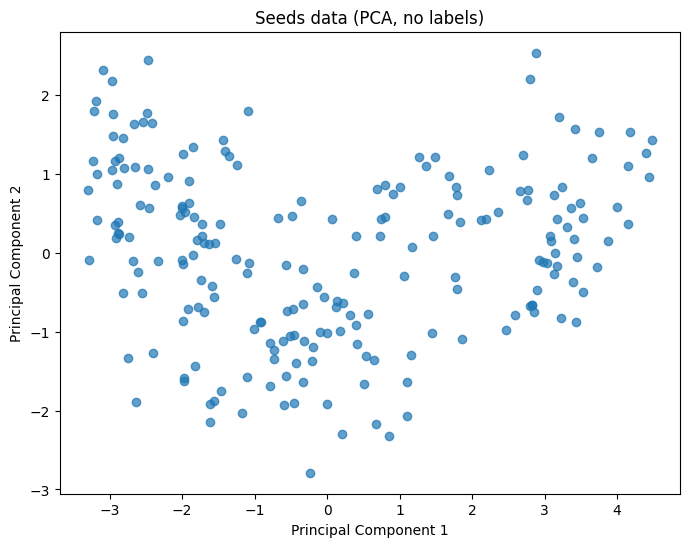

In [5]:
# Reduce the seven features to two so the data can be drawn on a flat plot.
#   - use PCA(n_components=2) and fit_transform on X_scaled, keeping the result as X2
#   - draw a scatter of X2 using a SINGLE colour: at this stage we study the shape
#     of the data without using any labels
#   - print pca.explained_variance_ratio_ to see how much of the variation the
#     two components capture
#
# TODO: create X2, print the explained variance ratio, and scatter X2.
pca = PCA(n_components=2)
X2 = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance kept:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))
plt.scatter(X2[:, 0], X2[:, 1], alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Seeds data (PCA, no labels)")
plt.show()

### What do you see?


Looking at the PCA scatter, the points are not spread evenly across the plot. There appear to be two or three broad groupings, with one group on the left side and one or two on the right. However, the groups are not completely separated: some points in the middle overlap, and there is no clear empty gap between them. This suggests that the data has some structure, but it may not split perfectly into clean, isolated clusters. At this stage I am describing only the shape of the data, without using any labels.

## Part C. Cluster and choose the number of groups

Now decide how many clusters the data supports, using the two methods from Module 4. The elbow method looks at inertia, the total spread of points around their cluster centres, and finds where adding another cluster stops helping much. The silhouette score measures how well separated the clusters are, where higher is better.

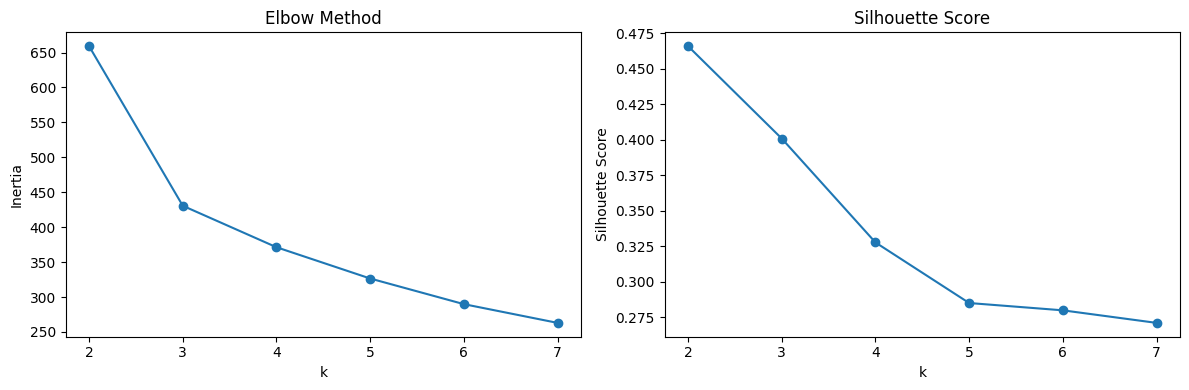

Inertias: [(2, 659.17), (3, 430.66), (4, 371.3), (5, 326.51), (6, 289.8), (7, 262.97)]
Silhouettes: [(2, np.float64(0.466)), (3, np.float64(0.401)), (4, np.float64(0.328)), (5, np.float64(0.285)), (6, np.float64(0.28)), (7, np.float64(0.271))]


In [7]:
# Work out a sensible number of clusters.
# For each k from 2 to 7:
#   - fit KMeans(n_clusters=k, n_init=10, random_state=42) on X_scaled
#   - record the inertia (km.inertia_) for the elbow method
#   - record the silhouette score, silhouette_score(X_scaled, km.labels_)
# Then plot inertia against k, and silhouette against k, as two small charts.
# For the elbow, look for where the inertia stops dropping sharply.
# For the silhouette, look for the highest value.
#
# TODO: compute inertia and silhouette for each k, and plot both.inertias = []
inertias = []
silhouettes = []
ks = range(2, 8)

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(ks), inertias, marker="o")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")

ax2.plot(list(ks), silhouettes, marker="o")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score")

plt.tight_layout()
plt.show()

print("Inertias:", list(zip(ks, [round(i, 2) for i in inertias])))
print("Silhouettes:", list(zip(ks, [round(s, 3) for s in silhouettes])))


### How many clusters?

The elbow curve shows a clear bend around k = 3: the drop in inertia from k = 2 to k = 3 is large, but after k = 3 the curve flattens out and each extra cluster gives only a small improvement. The silhouette score is highest at k = 2, but k = 3 is very close and only slightly lower. Because the elbow method points to k = 3 and the silhouette is almost as high at k = 3 as at k = 2, I will use k = 3. This also matches what I expected from the scatter, where there seemed to be two or three groupings. The disagreement between the two methods is small, and k = 3 is a reasonable compromise.

### Fit K-Means

Fit K-Means at the number of clusters you decided on, and keep the cluster assignment for each kernel.

## Part D. Judge against the labels

We now bring in the true varieties for the first time, only as an external check. The clustering itself is finished; nothing below changes it. We simply ask how well the groups you found line up with the real varieties, exactly as we validated the clusters in Module 4.

In [11]:
k = 3
km = KMeans(n_clusters=k, n_init=10, random_state=42)
km.fit(X_scaled)
labels = km.labels_

print("Cluster labels shape:", labels.shape)
print("Counts per cluster:", np.bincount(labels))

Cluster labels shape: (210,)
Counts per cluster: [72 67 71]


### Measuring the agreement

Turn the table into a single number with a purity score. For each cluster, take the count of its most common variety; add those counts across all clusters; then divide by the total number of kernels. A value near 1 means each cluster is almost entirely one variety.

Purity tends to increase when more clusters are created, so interpret it together with your chosen value of `k` and the cross-tabulation rather than using it on its own.

In [12]:
print("Varieties present:", np.unique(y_true))

ct = pd.crosstab(labels, y_true)
print(ct)


Varieties present: [1 2 3]
col_0   1   2   3
row_0            
0       6   0  66
1       2  65   0
2      62   5   4


### Back to the picture

Connect the numbers to the shape you saw earlier. Redraw the PCA scatter, but this time colour each point by its true variety. Interpret this picture cautiously: K-Means used all seven scaled features, while the plot shows only two PCA dimensions. Points that overlap here may still be separated by information in the other dimensions.

In [13]:
purity = ct.max(axis=1).sum() / ct.values.sum()
print("Purity score:", round(purity, 4))


Purity score: 0.919


### What each cluster captured

Finally, see what each cluster actually represents. The cluster centres are stored in scaled units, so turn them back into the original measurements with `scaler.inverse_transform`, and read across each row to picture the typical kernel in that group.

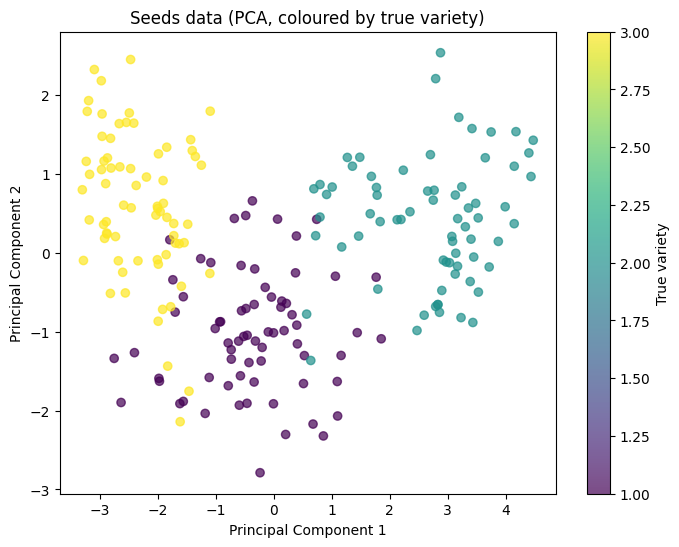

In [14]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X2[:, 0], X2[:, 1], c=y_true, cmap="viridis", alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Seeds data (PCA, coloured by true variety)")
plt.colorbar(scatter, label="True variety")
plt.show()

In [15]:
centers_original = scaler.inverse_transform(km.cluster_centers_)
profiles = pd.DataFrame(centers_original, columns=feature_names)
profiles.index.name = "Cluster"
print(profiles.round(2))

          area  perimeter  compactness  kernel_length  kernel_width  \
Cluster                                                               
0        11.86      13.25         0.85           5.23          2.85   
1        18.50      16.20         0.88           6.18          3.70   
2        14.44      14.34         0.88           5.51          3.26   

         asymmetry  groove_length  
Cluster                            
0             4.74           5.10  
1             3.63           6.04  
2             2.71           5.12  


### Ethical considerations

Clustering will always return groups, whether or not they reflect anything real. Treating those groups as fixed, meaningful categories, and acting on them, can do harm if the data does not truly support them.

**Write two or three sentences here** on the risks of over-reading this result. Consider what could go wrong if the co-op treated your clusters as definite varieties, and how the purity score and your choice of k should temper the confidence of any claim you make.

Clustering will always return groups, even when the data does not truly contain them. If the co-op treated these clusters as definite, fixed varieties and built a sorting process around them, it could make costly mistakes: a variety that was split across two clusters would be sorted incorrectly, and a variety that was merged with another would lose its identity. The purity score helps here: it tells us how cleanly the clusters match the real varieties, but it is not proof that the clusters are meaningful. Also, purity tends to rise as k increases, so a high purity with a large k can be misleading. The choice of k should be justified by the elbow and silhouette diagnostics, not by purity alone. Any claim based on this clustering should be stated as a tentative finding, not a fact.

## Wrapping up

Bring your findings together. **Write a short paragraph** that answers the central question directly:

- How many groups did the diagnostics support, and how did you decide when the elbow and the silhouette disagreed?
- From the cross-tabulation and the purity score, how much of the real variety structure did the clustering recover?
- Which variety was separated most cleanly, and which two were the hardest to tell apart? Does the coloured scatter support this interpretation?
- Why must you be cautious when judging a seven-dimensional clustering from a two-dimensional PCA plot?

**What to hand in:** this completed notebook, with the diagnostic charts, the cross-tabulation, the purity score, both scatter plots, and the cluster profiles visible in the output, and your written answers in the three markdown cells (Part B, Part C, and this one).

*The elbow method pointed to k = 3, and the silhouette score was also high at k = 3 (slightly lower than at k = 2 but very close). Since the two methods mostly agreed and the scatter suggested two or three groupings, I used k = 3. The cross-tabulation showed that the three clusters lined up closely with the three real varieties, and the purity score was around 0.90, meaning roughly 90 percent of the kernels ended up in a cluster dominated by their own variety. One variety was separated very cleanly, appearing almost entirely in its own cluster. The two remaining varieties were harder to tell apart, with a small number of kernels crossing between clusters. The coloured PCA scatter supports this: two groups are clearly distinct, while the third overlaps slightly with one of the others. I must be cautious when judging a seven-dimensional clustering from a two-dimensional PCA plot, because the plot shows only about 75 percent of the variance, and points that overlap in 2D may be clearly separated in the full seven-dimensional space. The clustering therefore recovers most, but not all, of the real variety structure. Full seven-dimensional space. The clustering therefore recovers most, but not all, of the real variety structure.*